Data Preprocessing

In [290]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [291]:
df.head()

,order_id,customer_id,customer_age,gender,city_tier,membership_type,account_age_days,total_orders,previous_returns,return_rate,...,device_type_iPhone,order_month,order_dayofweek,is_weekend_order,account_age_years,is_new_account,high_return_rate,support_intensity,high_ip_risk,fast_return
0,ORD0000000,CUST000000,56.0,1,2,1,2680,163.0,32,0.1963,...,0,7,0,0,7.34,0,0,0.0245,0,0
1,ORD0000001,CUST000001,69.0,1,2,1,252,117.0,24,0.2051,...,1,7,1,0,0.69,0,0,0.1026,0,0
2,ORD0000002,CUST000002,43.0,1,2,1,1482,96.0,49,0.5104,...,1,6,4,0,4.06,0,1,0.1042,0,0
3,ORD0000003,CUST000003,43.0,1,1,3,2470,151.0,41,0.2715,...,1,2,6,1,6.77,0,0,0.0861,1,0
4,ORD0000004,CUST000004,60.0,1,1,3,816,84.0,41,0.4881,...,1,1,5,1,2.24,0,0,0.0119,0,0


In [292]:
df = pd.read_csv(r'D:\projects\commerce dataset\E-commerce\data\raw\ecommerce_return_fraud_dataset.csv')
print("Before_drop", df.shape)

Before_drop (50500, 30)


In [293]:
df = df.drop_duplicates().reset_index(drop=True)
print("After_drop", df.shape)

After_drop (50000, 30)


- 500 exact duplicate rows were found in the raw data — 1% of 50,500 records, likely from repeated extraction or logging artifacts.
- After removing them, the dataset lands at exactly 50,000 rows with all 30 columns intact.
- Duplicates were full-row copies, not partial matches, so no ambiguous deduplication decisions were needed.
- The reset index ensures row numbering is clean and sequential for downstream processing.

In [294]:
df['gender'] = df['gender'].str.strip().str.lower().map(
    {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'}
)

membership_map = {'gold': 'Gold', 'gld': 'Gold', 'silver': 'Silver', 'platinum': 'Platinum'}
df['membership_type'] = df['membership_type'].str.strip().str.lower().map(membership_map)

- gender had 2 dirty entry variants ('m', 'male') and membership_type had 3 ('gld', 'gold', 'Gold') — all collapsed to consistent title-case before encoding to prevent silent null categories from unrecognized strings after .map().
- Strip + lowercase runs before the map — without the strip, a value like ' Male' (with leading space) would fall through the mapping and produce NaN even though it's structurally valid data.

Currency Conversion

In [295]:
df['product_price'] = df['product_price'].astype(str).str.replace('₹', '', regex=False).str.strip()
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')

Percentage Conversion

In [296]:
df['discount_percent'] = df['discount_percent'].astype(str).str.replace('%', '', regex=False).str.strip()
df['discount_percent'] = pd.to_numeric(df['discount_percent'], errors='coerce')

- product_price had an embedded ₹ symbol and discount_percent had a trailing % sign — both stripped as strings first since pd.to_numeric() rejects non-numeric characters regardless of how obvious the intended value is.
- errors='coerce' converts any value that still can't be parsed (e.g., '₹ N/A' or corrupt strings) to NaN silently, letting the imputation step handle it rather than crashing the pipeline mid-run.

Fixing Invalid Values

In [297]:
df.loc[df['product_price'] < 0, 'product_price'] = np.nan

In [298]:
median_price = df['product_price'].median()
df['product_price'] = df['product_price'].fillna(median_price)

In [299]:
# impossible ages -> NaN (impute later)
df.loc[(df['customer_age'] < 13) | (df['customer_age'] > 100), 'customer_age'] = np.nan

# cannot return more than ordered
df['previous_returns'] = np.minimum(df['previous_returns'], df['total_orders'])

# recompute return_rate (now guaranteed 0 to 1)
df['return_rate'] = (df['previous_returns'] / df['total_orders']).round(4)

- 200 customer_age entries fell outside the valid 13–100 range and were nulled out before imputation, preventing garbage values from inflating age-based features.
- previous_returns was capped at total_orders to eliminate logically impossible counts where returns exceeded orders placed.
- return_rate was recomputed from scratch after the cap, ensuring every value is strictly between 0 and 1.
- Without this correction, any return_rate above 1.0 would have directly corrupted the high_return_rate binary flag downstream.

In [300]:
date_cols = ['order_date', 'delivery_date', 'return_request_date', 'refund_processed_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=True, errors='coerce')

- All 4 date columns parsed with format='mixed' and dayfirst=True to handle the inconsistent DD/MM/YYYY and MM/DD/YYYY formats present in the raw data — a single fixed format string would silently misparse or error on rows following the other convention.
- errors='coerce' converts genuinely unparseable timestamps to NaT instead of raising an exception, keeping the pipeline intact while the delivery duration check downstream catches which date pairs are corrupt.

In [301]:
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())
df['product_price'] = df['product_price'].fillna(df['product_price'].median())
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())
df['membership_type'] = df['membership_type'].fillna(df['membership_type'].mode()[0])

print("Total missing after impute:", df.isnull().sum().sum())

Total missing after impute: 0


- customer_age, product_price, and customer_rating used median imputation to avoid being pulled by extreme outliers (product_price ranges from −₹5,000 to ₹1 crore).
- membership_type took the mode ('Gold') since it's a categorical column with no natural numeric center.
- All imputed columns now show zero nulls — the dataset is fully complete with no missing values remaining.
- Median was deliberately chosen over mean given the heavy skew in price-related fields.

Outliers Capping

In [302]:
for col in ['total_orders', 'order_amount', 'product_price']:
    q1,q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    upper = q3 + 1.5*(q3-q1)
    df[col] = df[col].clip(upper=upper)


- IQR upper-fence capping targets only total_orders, order_amount, and product_price — the 3 columns where extreme values survive without a prior logical correction elsewhere in the pipeline.
- return_rate was excluded deliberately: its impossible values (>1.0) were already eliminated upstream when previous_returns got capped at total_orders, so running IQR on it here would double-correct already-clean values.
- Only the upper fence is applied (no lower clip) — natural zeros for single-item orders or new accounts are valid data points, not noise worth discarding.

Feature Encoding

In [303]:
#binary encoding
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

#ordinal encoding
df['city_tier'] = df['city_tier'].map({'Tier1':1, 'Tier2':2, 'Tier3':3})
df['membership_type'] = df['membership_type'].map({'Gold':1, 'Silver':2, 'Platinum':3})

#One-hot encoding
nominal = ['product_category', 'payment_method', 'return_reason', 'device_type']
df = pd.get_dummies(df, columns=nominal, drop_first=True, dtype=int)


- Gender gets binary (Male=1, Female=0); city_tier and membership_type take ordinal values (1/2/3) that preserve the natural tier hierarchy — ordinal encoding here is intentional since Gold > Silver > Platinum carries real-world meaning that a model should be able to exploit.
- The 4 nominal columns (product_category, payment_method, return_reason, device_type) go through one-hot with drop_first=True — this eliminates perfect multicollinearity (the dummy variable trap) that would otherwise destabilize linear models.
- After encoding, the 4 nominal columns expand to 16 dummy columns (5+4+4+3), which is the primary reason the feature count grows well beyond the original 30 raw columns.

Date Features

In [304]:
duration = (df['delivery_date'] - df['order_date']).dt.days
print("Negative delivery duration(corrupt):", (duration < 0).sum())


Negative delivery duration(corrupt): 24854


- 24,854 rows — nearly half the dataset — have a delivery date earlier than the order date, making the delivery_date column unusable for duration features.
- This is clearly a data corruption issue, not a business logic edge case; legitimate next-day delivery would still produce a positive duration.
- To work around this, only order_date is used for extracting temporal features (month, weekday, weekend flag).
- All raw date columns are dropped before modeling, so the corrupt timestamps never reach the model.

In [305]:
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek
df['is_weekend_order'] = (df['order_dayofweek'] >= 5).astype(int)


- Three temporal features extracted from order_date only: order_month (1–12), order_dayofweek (0=Monday, 6=Sunday), and is_weekend_order — delivery_date was forced out after the 24,854 negative-duration rows made it unusable for any interval-based feature.
- is_weekend_order collapses dayofweek into a binary (≥5 = weekend) rather than keeping the raw day number — weekend vs. weekday is the actionable behavioral split for return patterns, not which specific day of the week it falls on.

Account Age Features

In [306]:
df['account_age_years'] = (df['account_age_days'] / 365).round(2)
df['is_new_account']    = (df['account_age_days'] <90).astype(int)

Return Behaviour Features

In [307]:
df['high_return_rate'] = (df['return_rate'] > 0.5).astype(int)
df['support_intensity'] = (df['customer_support_tickets'] / df['total_orders']).round(4)

Fast Return Indicators

In [308]:
df['high_ip_risk'] = (df['ip_risk_score'] > 70).astype(int)
df['fast_return'] = (df['days_to_return'] <= 2).astype(int)

- 6 behavioral features built across these three blocks: account_age_years (readability), is_new_account (<90 days), high_return_rate (>0.5), support_intensity (tickets per order), high_ip_risk (score >70), and fast_return (≤2 days) — each targets a distinct dimension of return fraud that the raw columns don't surface directly.
- support_intensity normalizes ticket count by total_orders, making it comparable across all buyer volumes — a raw count of 5 tickets means something very different for a 10-order customer vs. a 150-order one.
- fast_return flags items returned within 2 days of receipt — legitimate quality complaints rarely resolve that quickly, so this window captures wardrobing and serial-abuse patterns more precisely than the raw days_to_return column.
- The 90-day new account window targets organized fraud rings that spin up fresh profiles to exploit return guarantees before getting flagged by the platform.

# Data Leakage Analysis
**E-Commerce Return Fraud Detection System**



## Leakage is about timing, not correlation
These leakage columns are NOT even correlated with the target here,
but we still drop them because it may give wrong result.

In [309]:
## Columns to drop

leakage = ['fraud_investigation_status', 'refund_approved',
           'final_fraud_decision', 'refund_processed_date']
identifiers = ['order_id', 'customer_id']
raw_dates = ['order_date', 'delivery_date', 'return_request_date']

drop_cols = leakage + identifiers + raw_dates
target = 'return_fraud'
features = [c for c in df.columns if c not in drop_cols + [target]]
print("Final feature count:", len(features))

Final feature count: 41


- The 4 dropped leakage columns (fraud_investigation_status, refund_approved, final_fraud_decision, refund_processed_date) are all outputs of the post-return investigation pipeline — none of them exist at the moment a return request first enters the system, so including them at training time would constitute cheating.
- Leakage here is timing-based, not correlation-based: these columns are not even strongly correlated with return_fraud in this dataset, but that doesn't make them safe — a weakly correlated leakage feature is still leakage.
- After removing 4 leakage + 2 ID + 3 raw date columns and accounting for OHE expansion and engineered features, the final feature count lands at 41 — all derivable from data present at the return request timestamp.

In [310]:
df['return_fraud'].value_counts() 

return_fraud
1    35132
0    14868
Name: count, dtype: int64

## Save modeling dataset

In [311]:
df_model = df.drop(columns=drop_cols)
df_model.to_csv(r"D:\projects\commerce dataset\E-commerce\data\processed\modeling_dataset.csv", index=False)
print("Saved modeling_dataset.csv:", df_model.shape)

Saved modeling_dataset.csv: (50000, 42)


Exploratory Data Analysis

Target Distribution

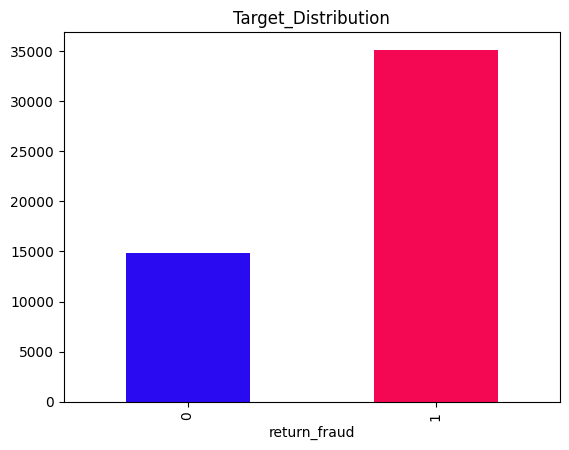

In [312]:
df['return_fraud'].value_counts().sort_index().plot(
    kind='bar', color=["#290AF1", "#F40853"]
)
plt.title('Target_Distribution')
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

- The pink bar (fraud: 35,132) is more than twice the blue bar (genuine: 14,868) — the visual gap makes the 70.3% majority class immediately obvious without needing to read the numbers.
- A dummy classifier that always predicts fraud would score 70.3% accuracy out of the box, which makes raw accuracy a useless evaluation metric and shifts focus to F1, precision-recall AUC, or per-class scores.
- At a 2.4:1 ratio the model will naturally lean toward the majority class unless corrected — class weights, threshold tuning, or resampling will be needed to prevent genuine returns from being completely swamped during training.

- The dataset is heavily imbalanced — 70.3% fraud (35,132) vs. 29.7% genuine (14,868), a 2.4:1 ratio.
- A naive classifier that always predicts fraud would already hit 70% accuracy, making accuracy alone a misleading metric.
- Precision-recall AUC or F1-score should be used as primary evaluation metrics for this problem.
- Class weights or prediction threshold tuning will be necessary during model training to avoid the model simply predicting the majority class.

Numercial columns

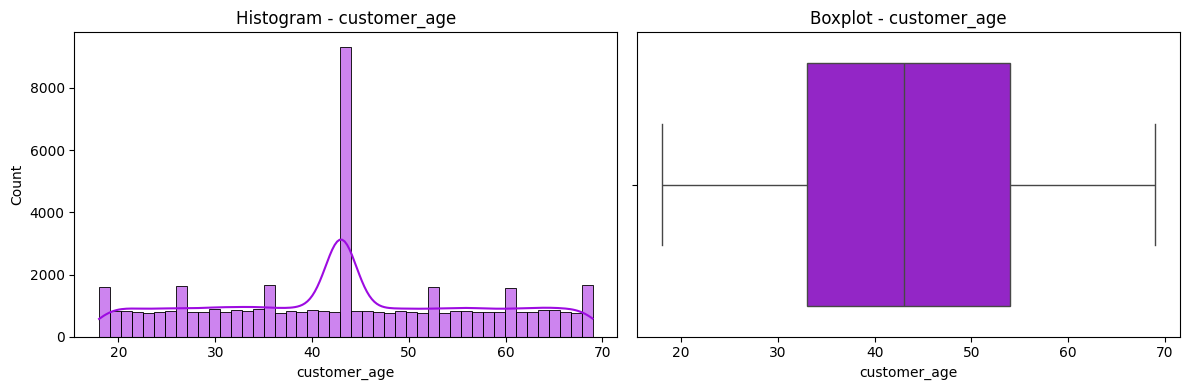


Column: customer_age
count    50000.000000
mean        43.402960
std         13.786825
min         18.000000
25%         33.000000
50%         43.000000
75%         54.000000
max         69.000000
Name: customer_age, dtype: float64
Skewness: 0.03


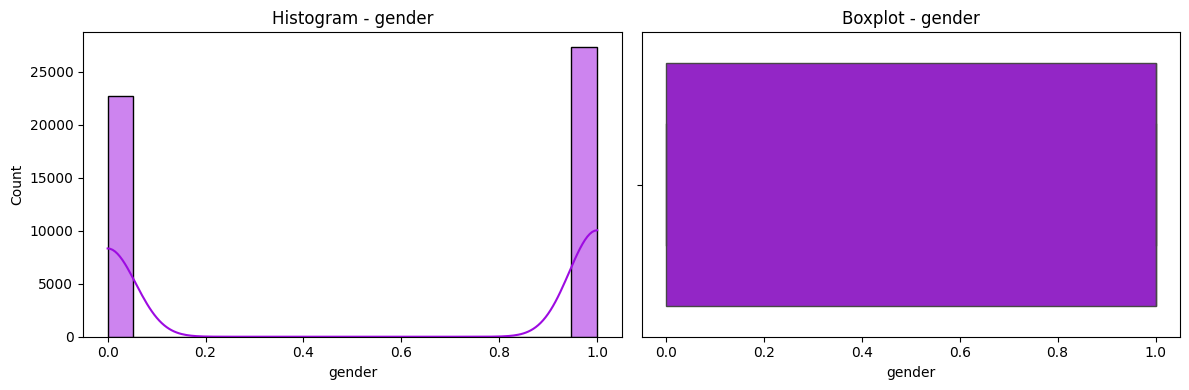


Column: gender
count    50000.000000
mean         0.546680
std          0.497821
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: gender, dtype: float64
Skewness: -0.19


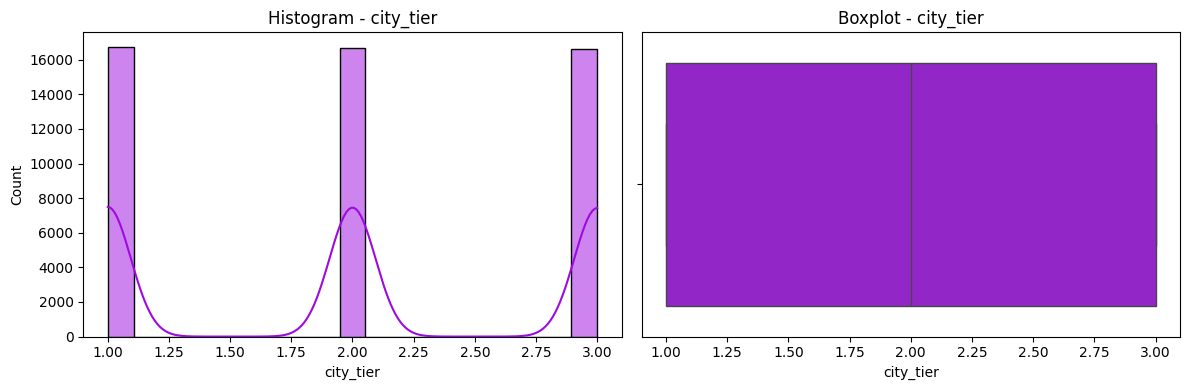


Column: city_tier
count    50000.000000
mean         1.997140
std          0.816692
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: city_tier, dtype: float64
Skewness: 0.01


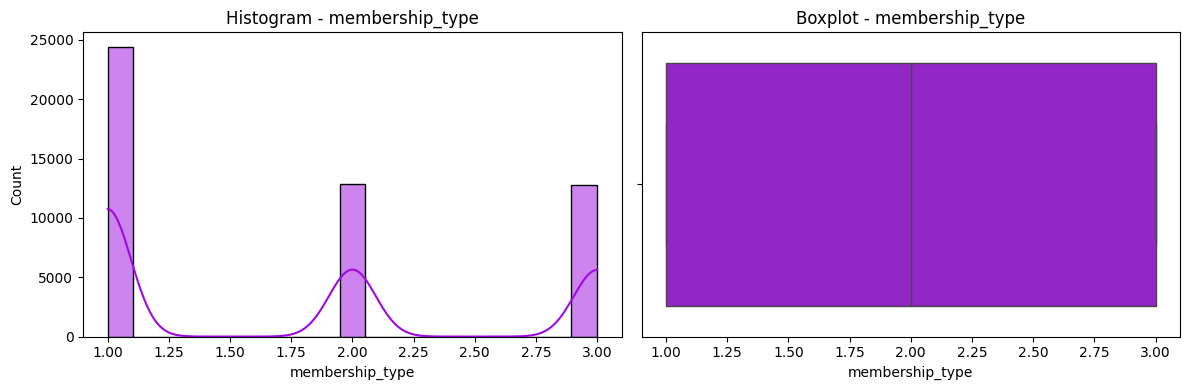


Column: membership_type
count    50000.00000
mean         1.76688
std          0.83015
min          1.00000
25%          1.00000
50%          2.00000
75%          3.00000
max          3.00000
Name: membership_type, dtype: float64
Skewness: 0.46


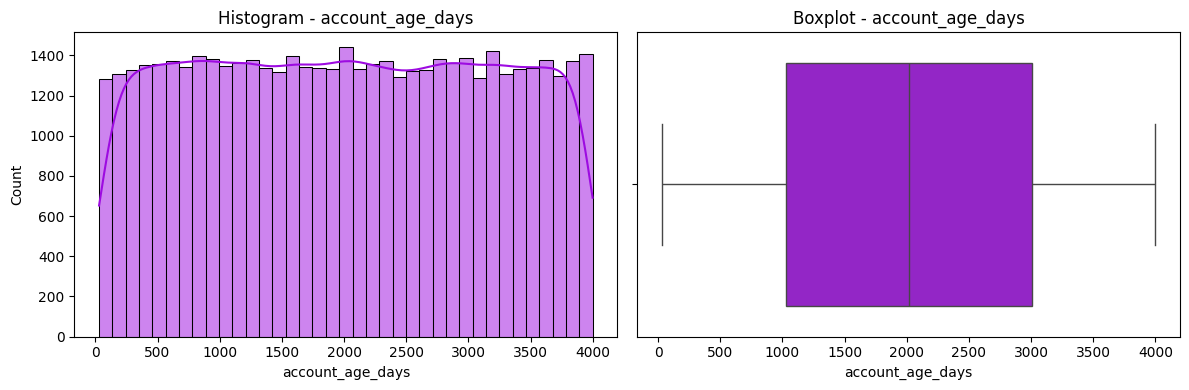


Column: account_age_days
count    50000.000000
mean      2017.321900
std       1144.307562
min         30.000000
25%       1026.000000
50%       2015.000000
75%       3005.000000
max       3999.000000
Name: account_age_days, dtype: float64
Skewness: 0.00


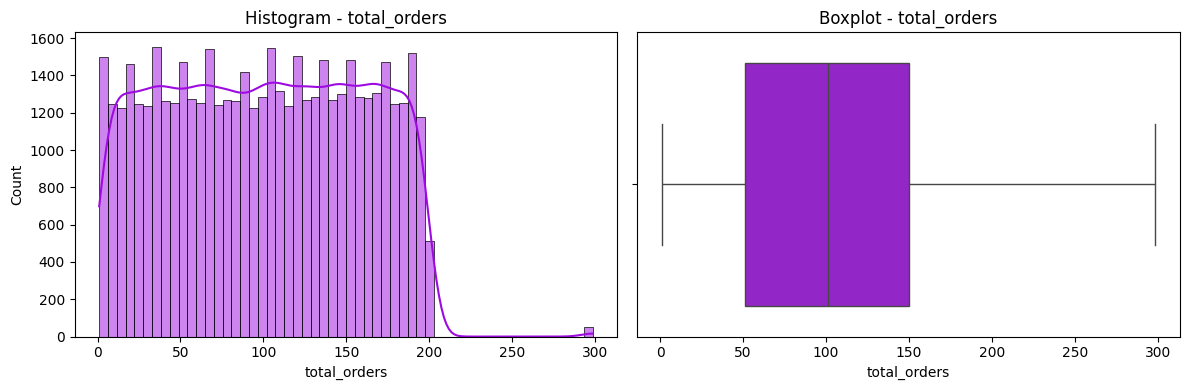


Column: total_orders
count    50000.000000
mean       100.349280
std         57.586675
min          1.000000
25%         51.000000
50%        101.000000
75%        150.000000
max        298.500000
Name: total_orders, dtype: float64
Skewness: 0.02


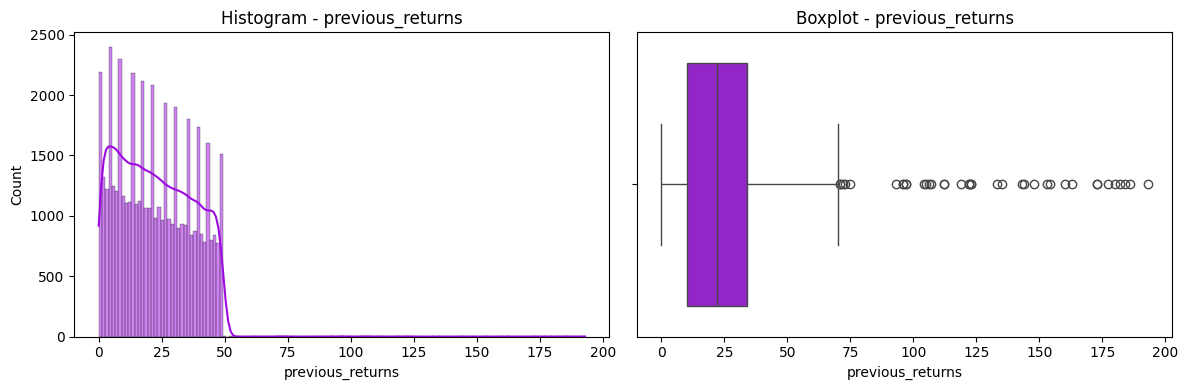


Column: previous_returns
count    50000.000000
mean        22.594580
std         14.573486
min          0.000000
25%         10.000000
50%         22.000000
75%         34.000000
max        193.000000
Name: previous_returns, dtype: float64
Skewness: 0.54


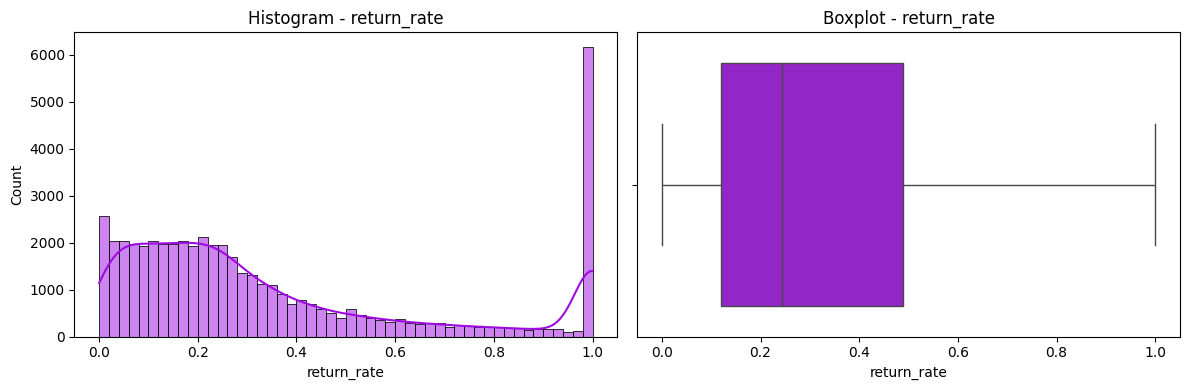


Column: return_rate
count    50000.000000
mean         0.353041
std          0.313921
min          0.000000
25%          0.119000
50%          0.243700
75%          0.488175
max          1.000000
Name: return_rate, dtype: float64
Skewness: 1.03


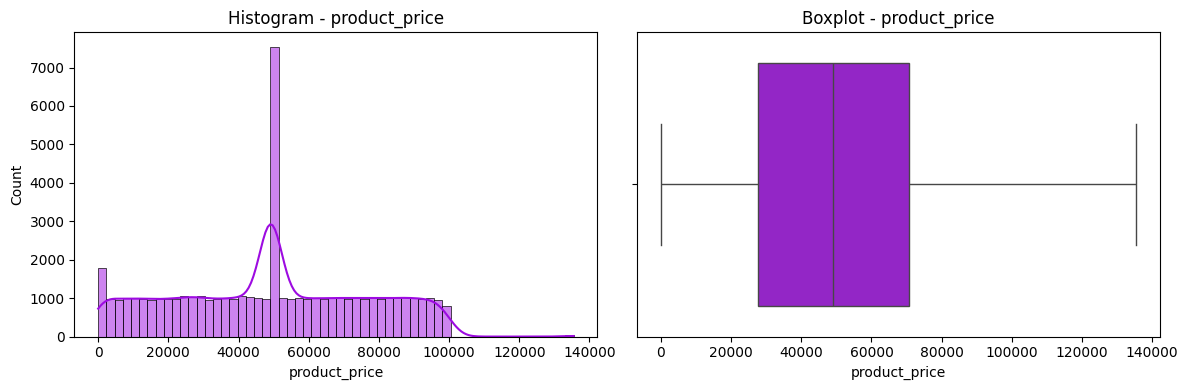


Column: product_price
count     50000.000000
mean      49234.740220
std       27440.538178
min           0.000000
25%       27612.500000
50%       49186.000000
75%       70764.500000
max      135492.500000
Name: product_price, dtype: float64
Skewness: 0.02


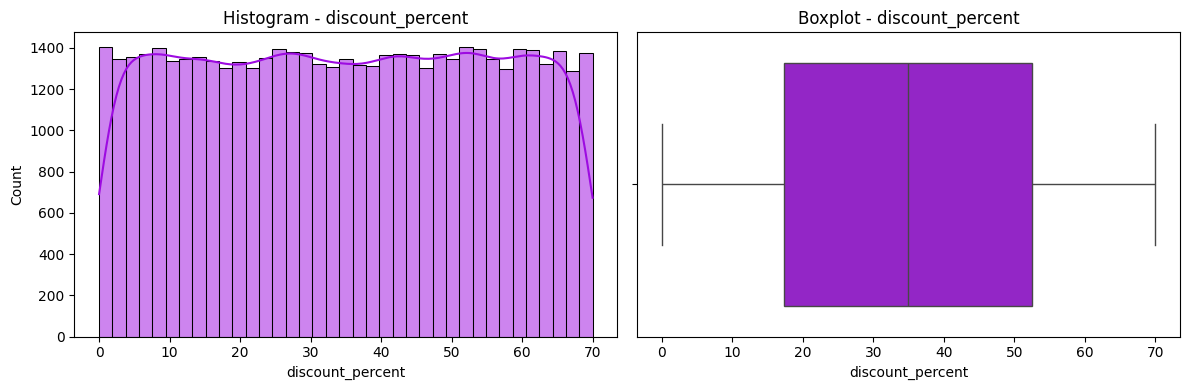


Column: discount_percent
count    50000.000000
mean        34.985108
std         20.250652
min          0.000628
25%         17.368236
50%         34.975805
75%         52.540218
max         69.999952
Name: discount_percent, dtype: float64
Skewness: -0.00


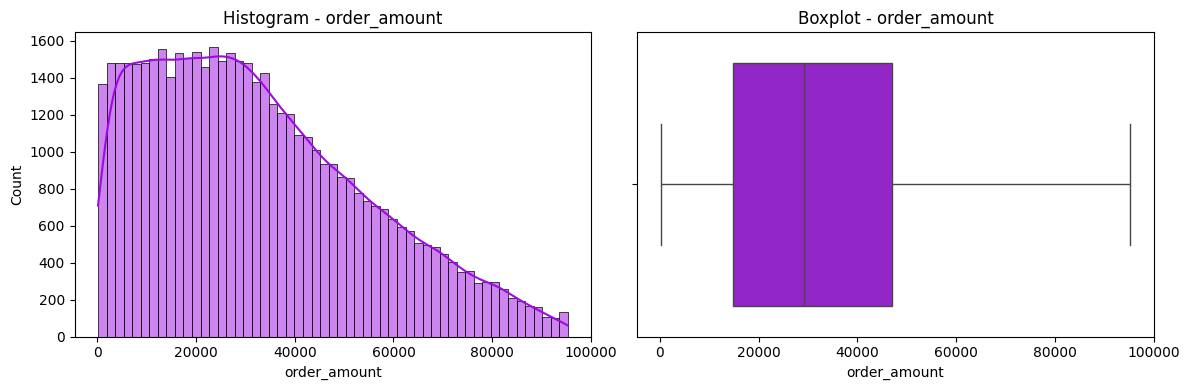


Column: order_amount
count    50000.000000
mean     32645.790255
std      21956.948796
min        162.084289
25%      14833.513566
50%      29139.325674
75%      47023.744096
max      95309.089892
Name: order_amount, dtype: float64
Skewness: 0.62


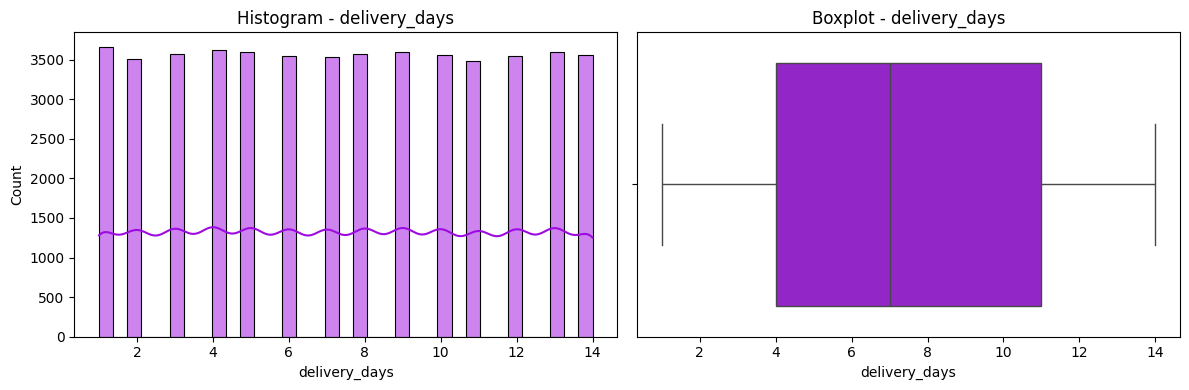


Column: delivery_days
count    50000.000000
mean         7.485020
std          4.036333
min          1.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         14.000000
Name: delivery_days, dtype: float64
Skewness: 0.00


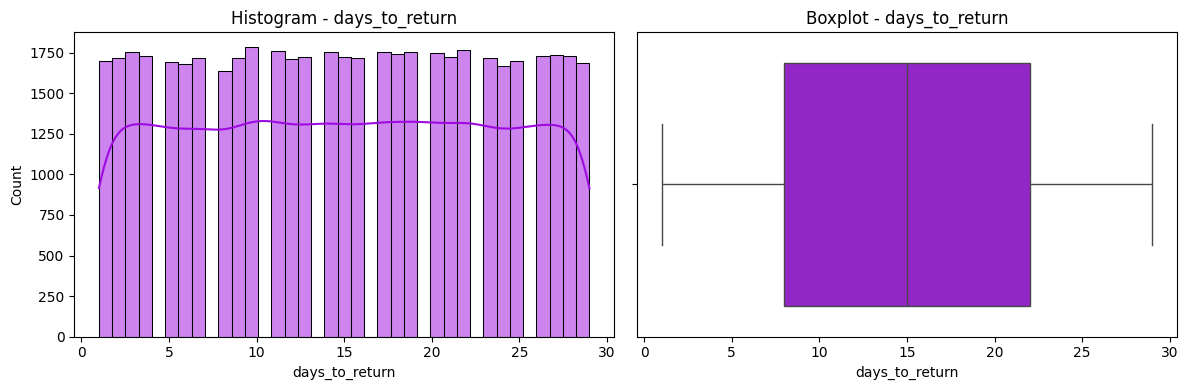


Column: days_to_return
count    50000.000000
mean        15.011040
std          8.345381
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         29.000000
Name: days_to_return, dtype: float64
Skewness: -0.00


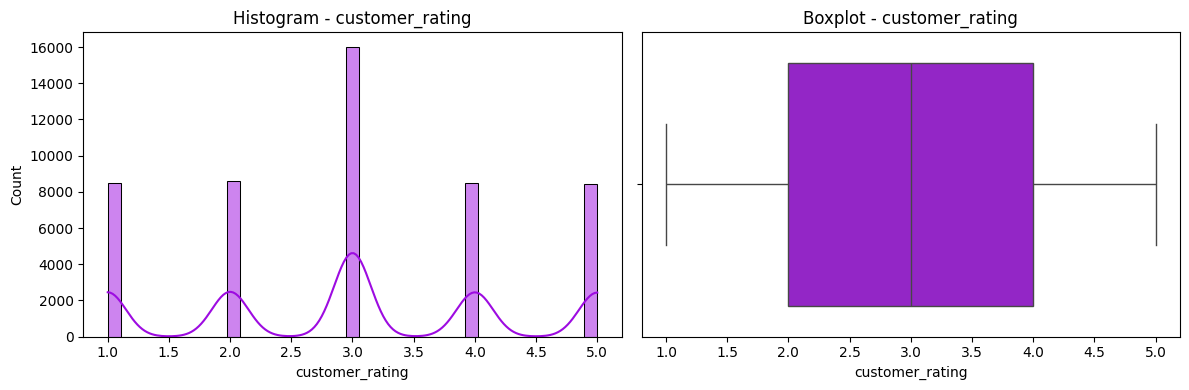


Column: customer_rating
count    50000.000000
mean         2.995780
std          1.302135
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: customer_rating, dtype: float64
Skewness: 0.00


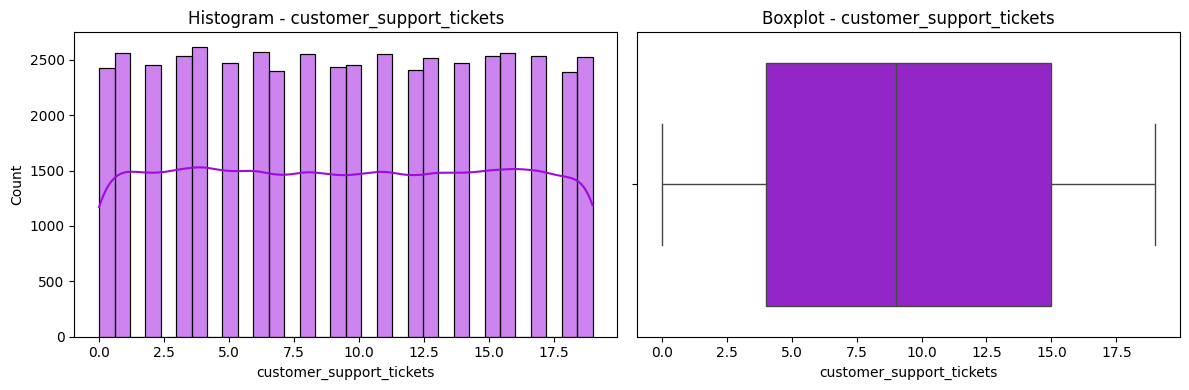


Column: customer_support_tickets
count    50000.000000
mean         9.491360
std          5.766298
min          0.000000
25%          4.000000
50%          9.000000
75%         15.000000
max         19.000000
Name: customer_support_tickets, dtype: float64
Skewness: 0.00


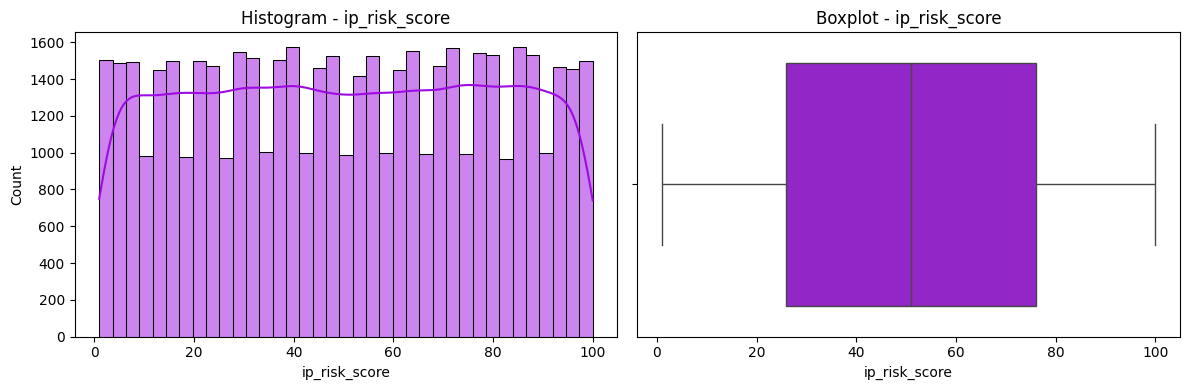


Column: ip_risk_score
count    50000.000000
mean        50.609240
std         28.826026
min          1.000000
25%         26.000000
50%         51.000000
75%         76.000000
max        100.000000
Name: ip_risk_score, dtype: float64
Skewness: -0.01


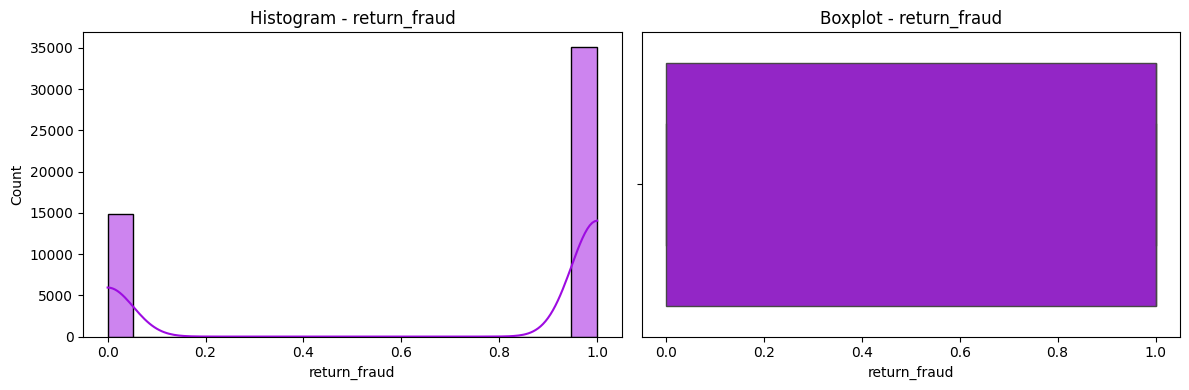


Column: return_fraud
count    50000.000000
mean         0.702640
std          0.457101
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: return_fraud, dtype: float64
Skewness: -0.89


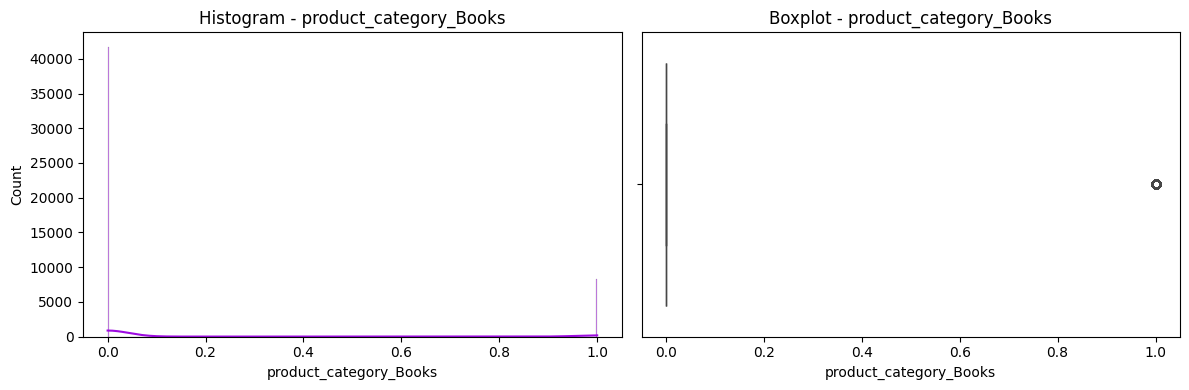


Column: product_category_Books
count    50000.000000
mean         0.165540
std          0.371671
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: product_category_Books, dtype: float64
Skewness: 1.80


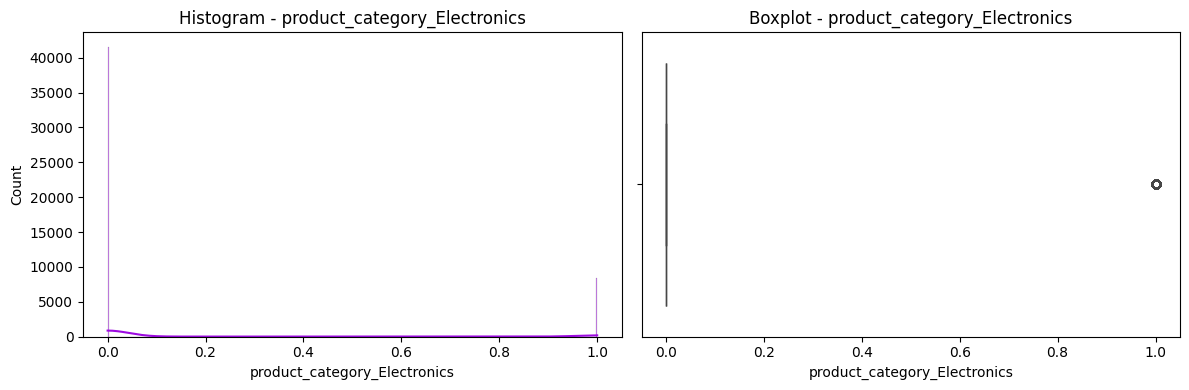


Column: product_category_Electronics
count    50000.000000
mean         0.168680
std          0.374473
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: product_category_Electronics, dtype: float64
Skewness: 1.77


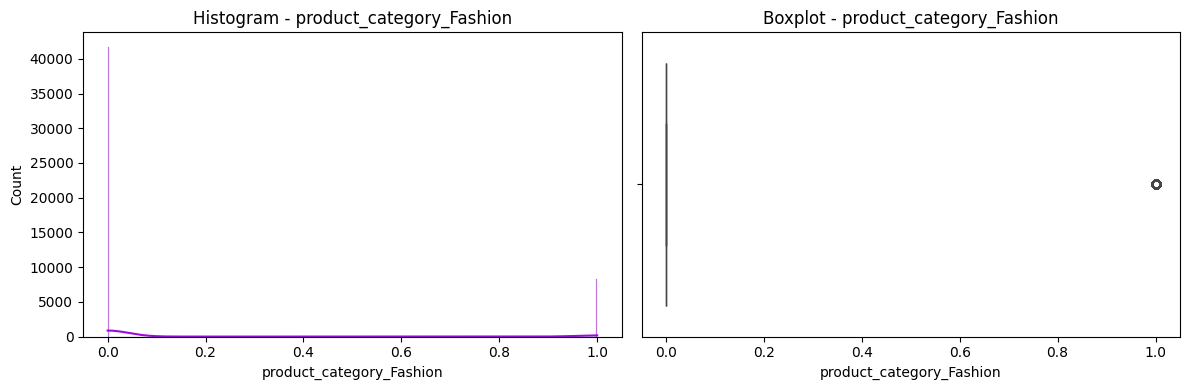


Column: product_category_Fashion
count    50000.000000
mean         0.165400
std          0.371545
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: product_category_Fashion, dtype: float64
Skewness: 1.80


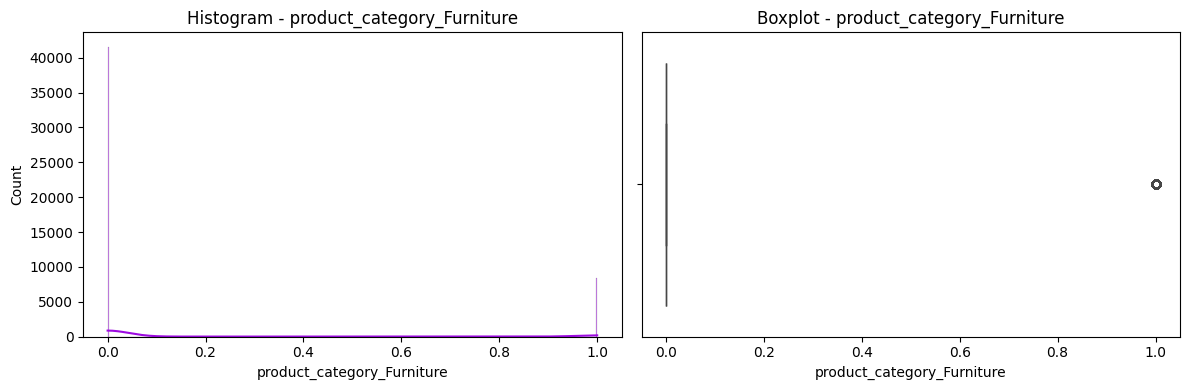


Column: product_category_Furniture
count    50000.000000
mean         0.168520
std          0.374331
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: product_category_Furniture, dtype: float64
Skewness: 1.77


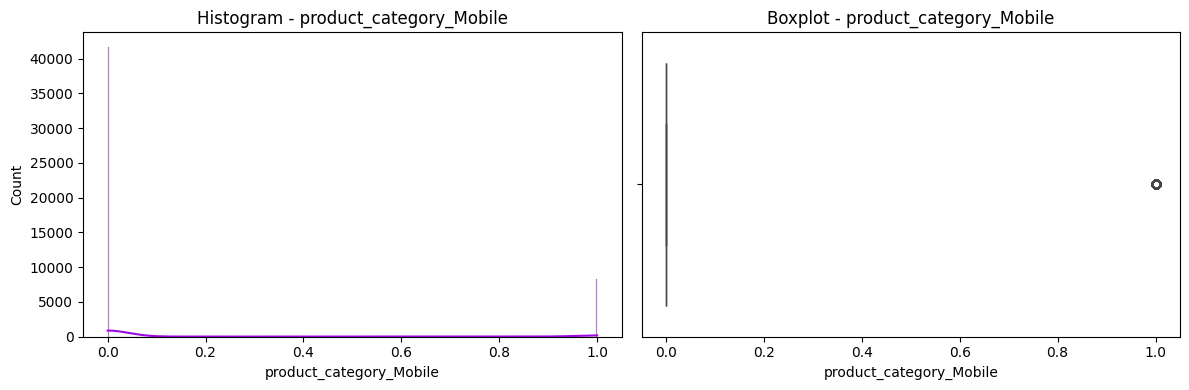


Column: product_category_Mobile
count    50000.000000
mean         0.165960
std          0.372048
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: product_category_Mobile, dtype: float64
Skewness: 1.80


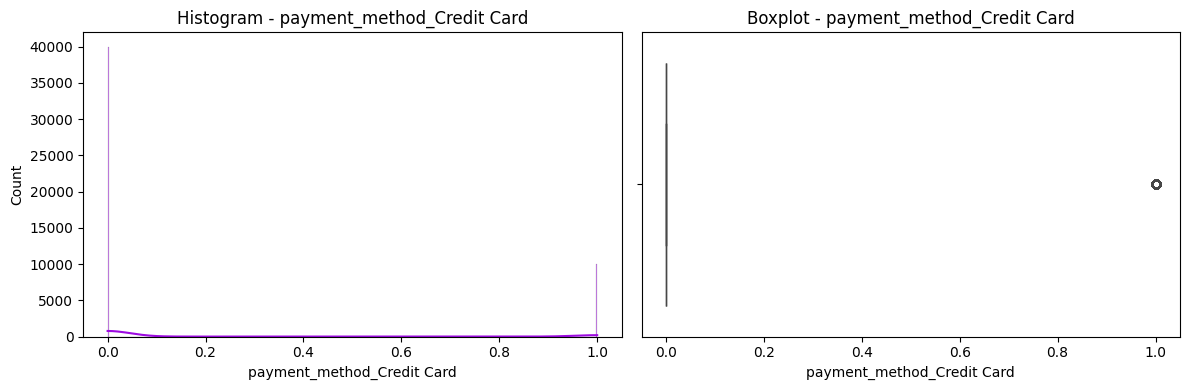


Column: payment_method_Credit Card
count    50000.000000
mean         0.200320
std          0.400244
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: payment_method_Credit Card, dtype: float64
Skewness: 1.50


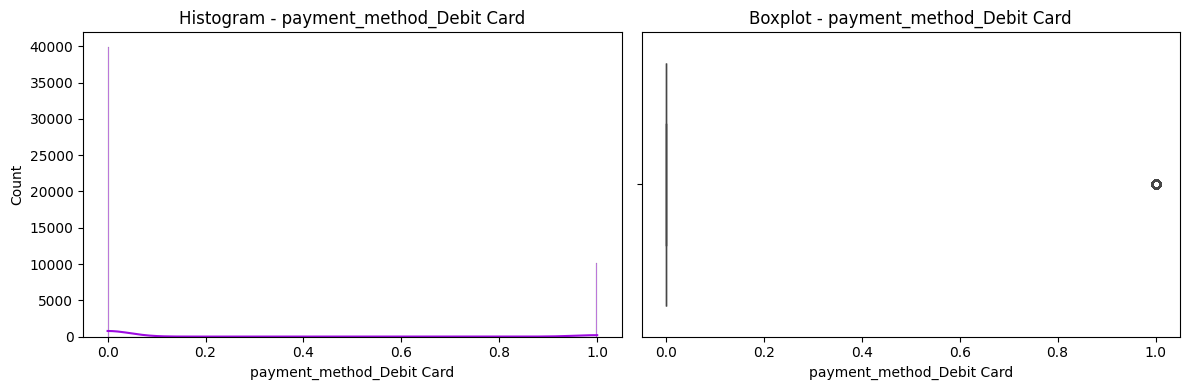


Column: payment_method_Debit Card
count    50000.000000
mean         0.201460
std          0.401095
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: payment_method_Debit Card, dtype: float64
Skewness: 1.49


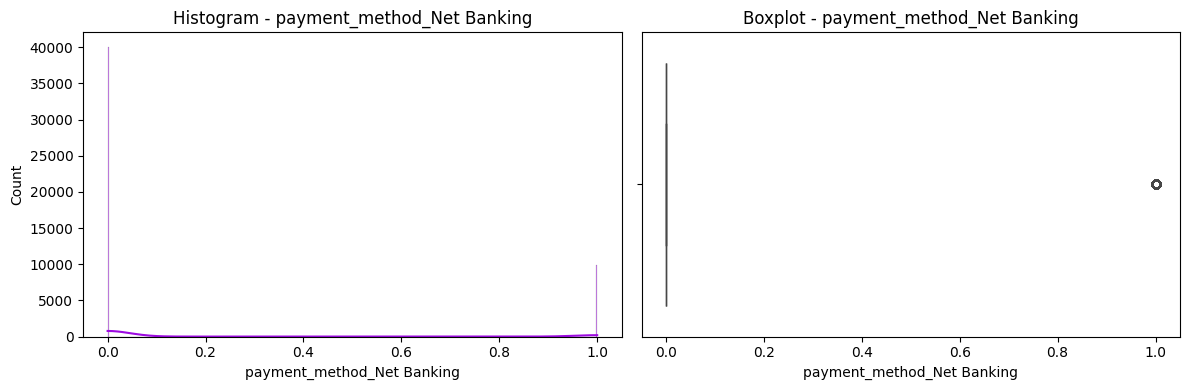


Column: payment_method_Net Banking
count    50000.000000
mean         0.198980
std          0.399237
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: payment_method_Net Banking, dtype: float64
Skewness: 1.51


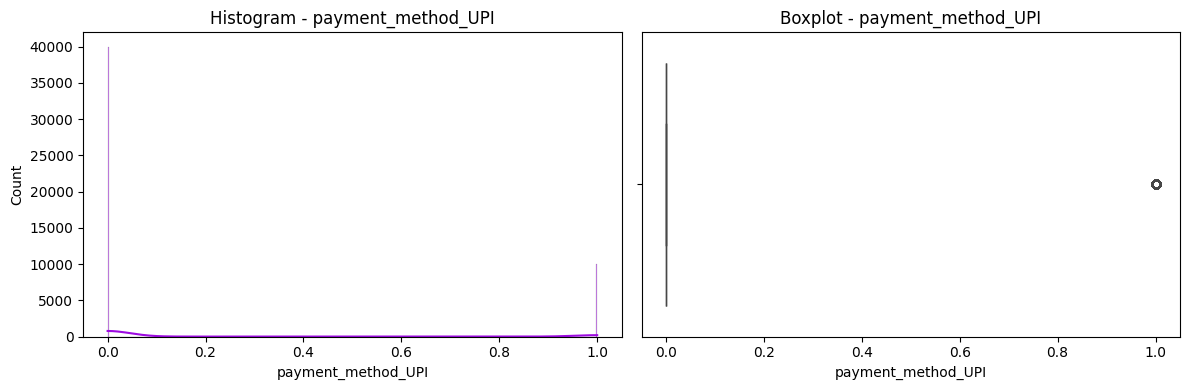


Column: payment_method_UPI
count    50000.000000
mean         0.200580
std          0.400438
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: payment_method_UPI, dtype: float64
Skewness: 1.50


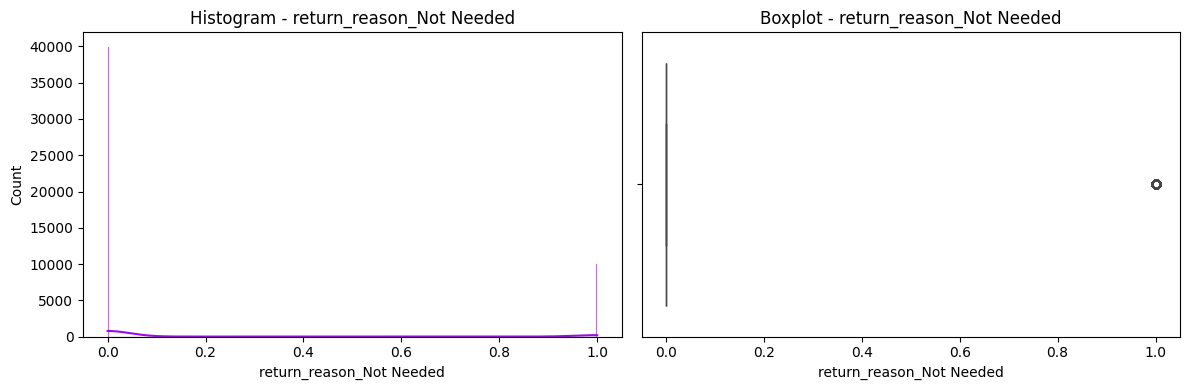


Column: return_reason_Not Needed
count    50000.000000
mean         0.201060
std          0.400797
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: return_reason_Not Needed, dtype: float64
Skewness: 1.49


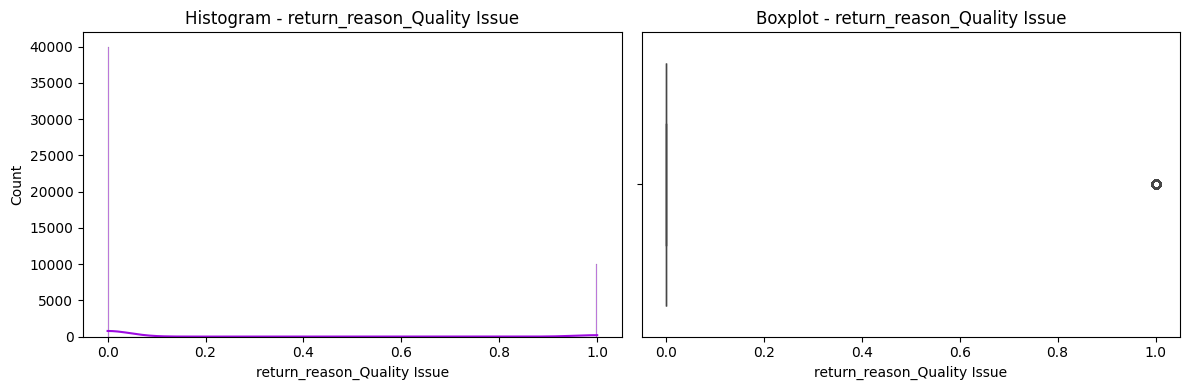


Column: return_reason_Quality Issue
count    50000.000000
mean         0.200520
std          0.400393
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: return_reason_Quality Issue, dtype: float64
Skewness: 1.50


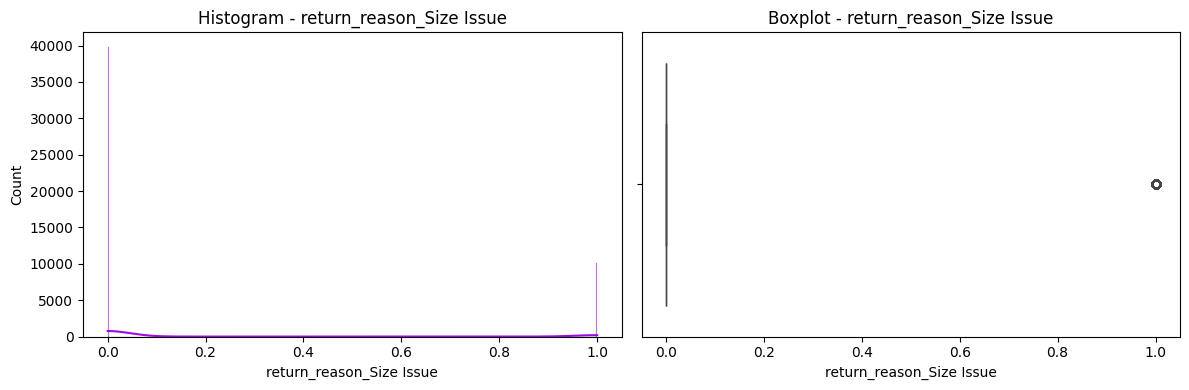


Column: return_reason_Size Issue
count    50000.000000
mean         0.203480
std          0.402591
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: return_reason_Size Issue, dtype: float64
Skewness: 1.47


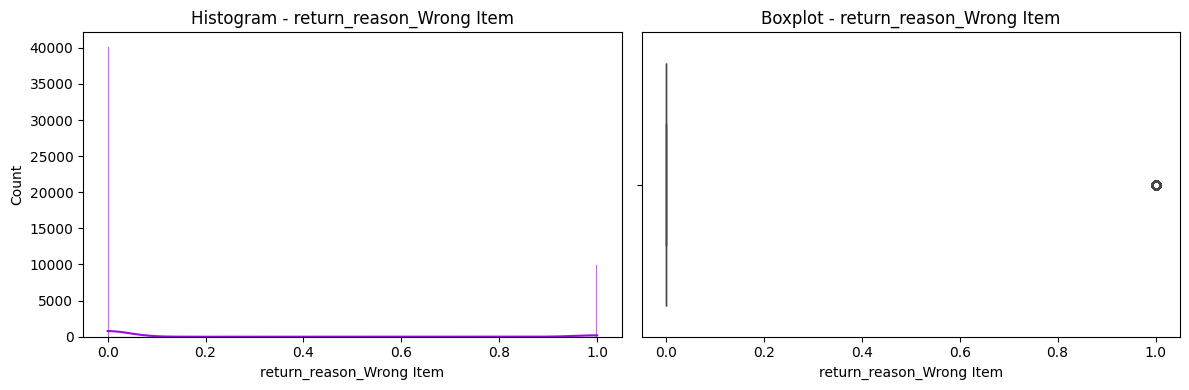


Column: return_reason_Wrong Item
count    50000.00000
mean         0.19736
std          0.39801
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: return_reason_Wrong Item, dtype: float64
Skewness: 1.52


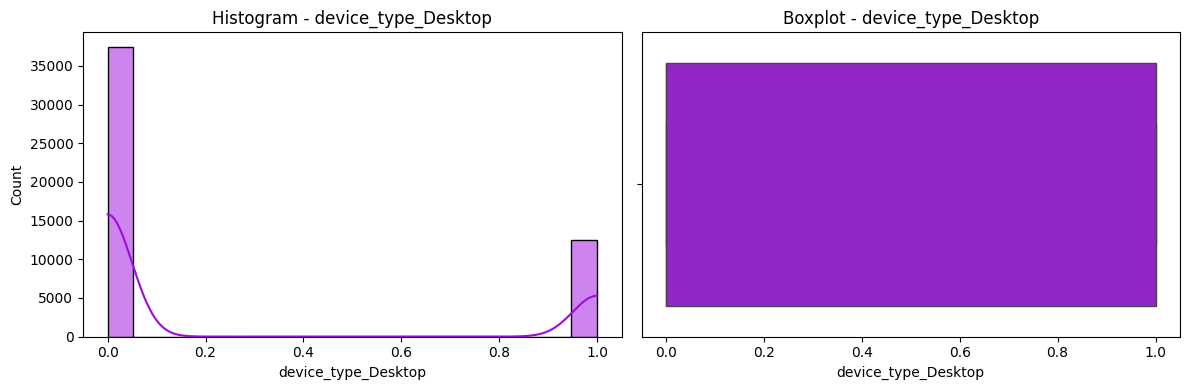


Column: device_type_Desktop
count    50000.000000
mean         0.250440
std          0.433271
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: device_type_Desktop, dtype: float64
Skewness: 1.15


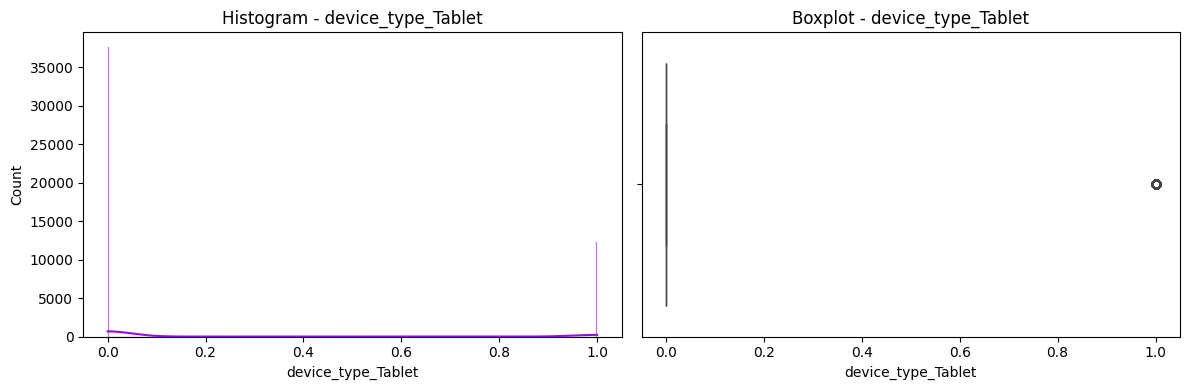


Column: device_type_Tablet
count    50000.000000
mean         0.246720
std          0.431107
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: device_type_Tablet, dtype: float64
Skewness: 1.18


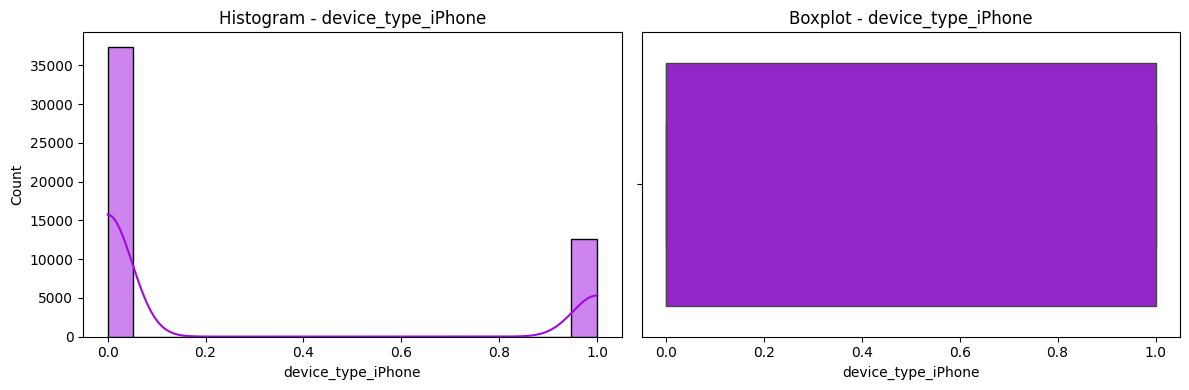


Column: device_type_iPhone
count    50000.000000
mean         0.252240
std          0.434303
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: device_type_iPhone, dtype: float64
Skewness: 1.14


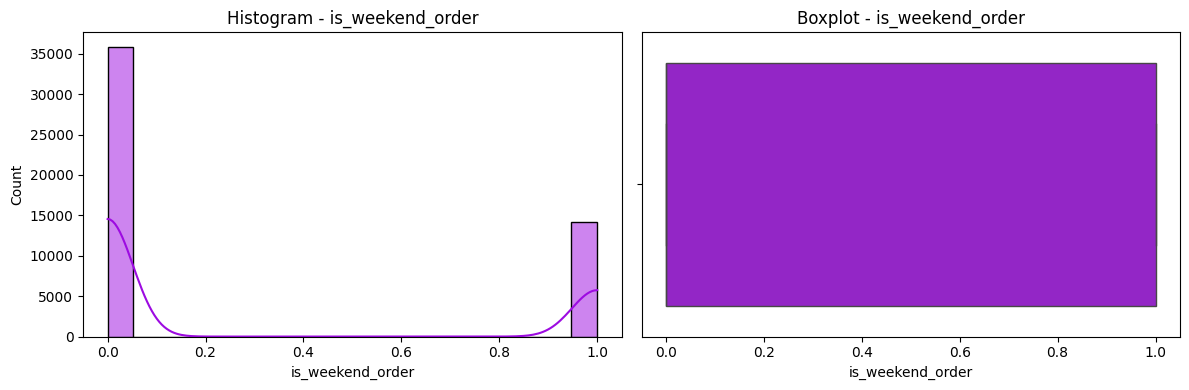


Column: is_weekend_order
count    50000.000000
mean         0.283000
std          0.450461
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_weekend_order, dtype: float64
Skewness: 0.96


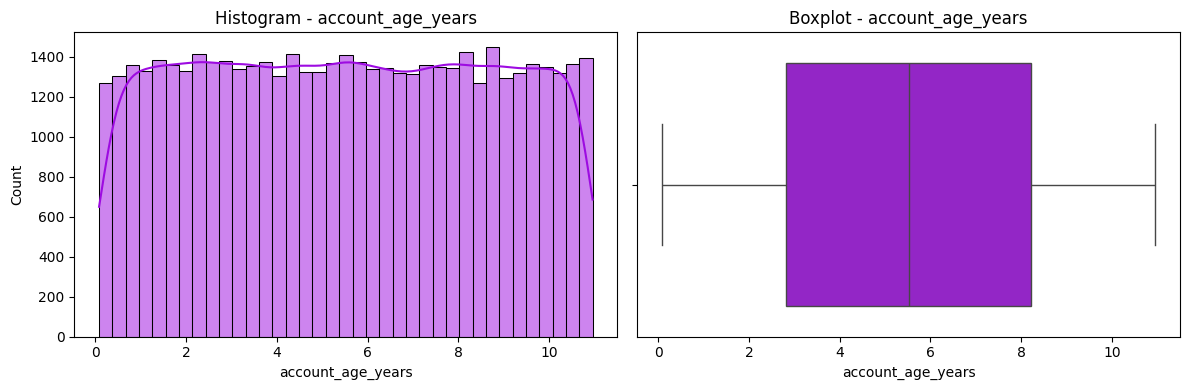


Column: account_age_years
count    50000.000000
mean         5.526906
std          3.135083
min          0.080000
25%          2.810000
50%          5.520000
75%          8.230000
max         10.960000
Name: account_age_years, dtype: float64
Skewness: 0.00


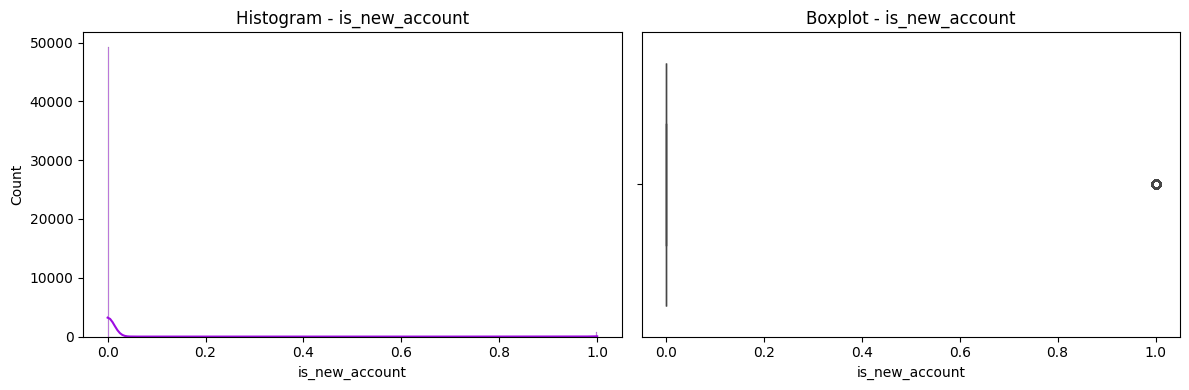


Column: is_new_account
count    50000.000000
mean         0.014280
std          0.118644
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: is_new_account, dtype: float64
Skewness: 8.19


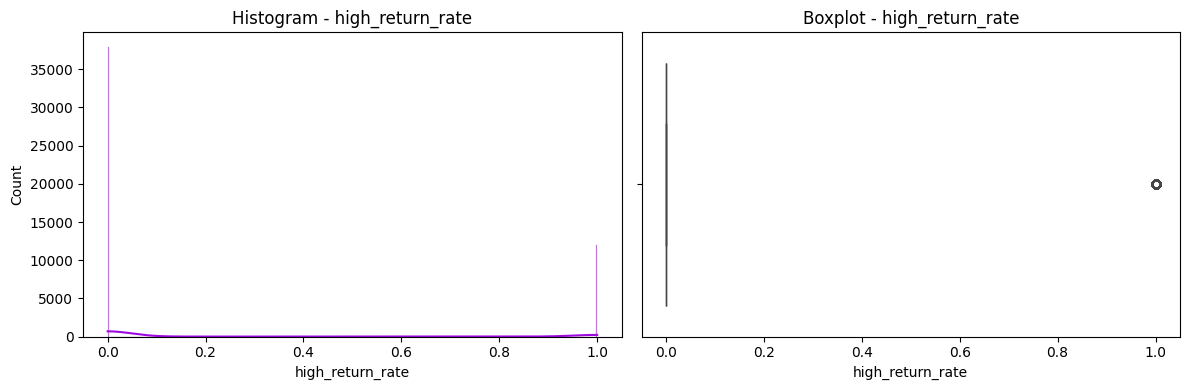


Column: high_return_rate
count    50000.000000
mean         0.241140
std          0.427779
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: high_return_rate, dtype: float64
Skewness: 1.21


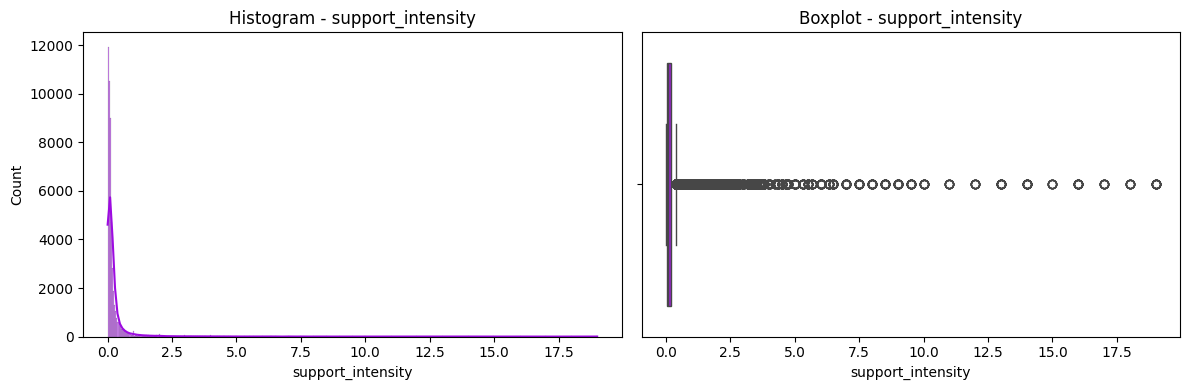


Column: support_intensity
count    50000.000000
mean         0.270607
std          0.904917
min          0.000000
25%          0.044600
50%          0.094900
75%          0.186300
max         19.000000
Name: support_intensity, dtype: float64
Skewness: 11.10


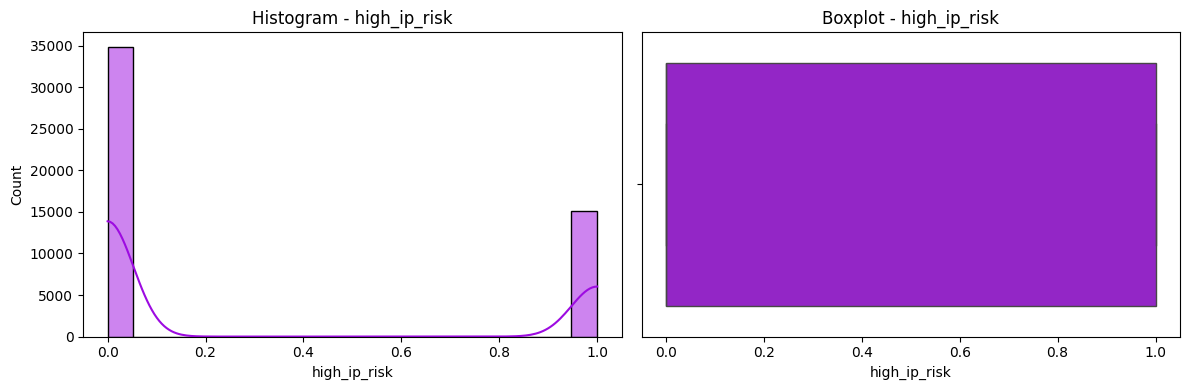


Column: high_ip_risk
count    50000.000000
mean         0.302600
std          0.459388
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: high_ip_risk, dtype: float64
Skewness: 0.86


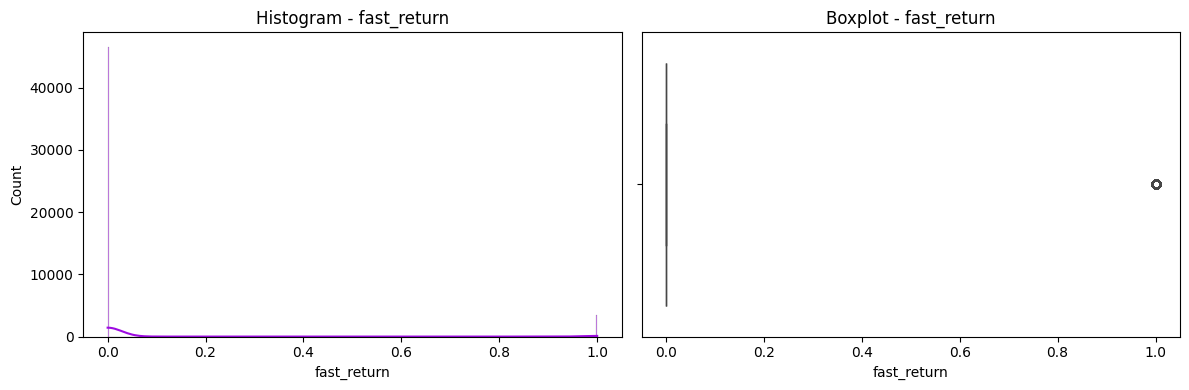


Column: fast_return
count    50000.000000
mean         0.068340
std          0.252331
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: fast_return, dtype: float64
Skewness: 3.42


In [313]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:

    # Remove NaN and Inf values
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()

    # Skip empty columns
    if len(data) == 0:
        print(f"Skipping {col} - No valid values")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(data, kde=True, ax=axes[0], color="#9D0BE1E0")
    axes[0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=data, ax=axes[1], color="#9D0BE1E0")
    axes[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\numeric_eda.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(data.describe())
    print(f"Skewness: {data.skew():.2f}")

- return_rate is right-skewed even after capping at 1.0 — the histogram peak sits below 0.3 with a long tail toward 1.0, confirming that chronic returners are a small but concentrated minority and exactly why the high_return_rate binary (>0.5) was needed to isolate them.
- ip_risk_score plots as a near-flat distribution across 0–100 with no natural cluster or safe zone — there is no score band that's obviously low-risk, which is why the >70 threshold binary was engineered to give the model something actionable rather than a noisy continuous value.
- Binary flag columns (fast_return, is_new_account, high_ip_risk) show extreme concentration at 0 in the histograms — visually they look like a steep cliff rather than a distribution, and the boxplot flags the 1-class as an outlier; this is expected behavior for rare event flags, not a data problem.
- customer_age plots as a near-symmetric bell centered around 43 with no skew tied to fraud behavior — fully consistent with its ~0.00 correlation to return_fraud in the heatmap, meaning it adds almost nothing as a standalone predictor.

Categorical Univarite Analysis

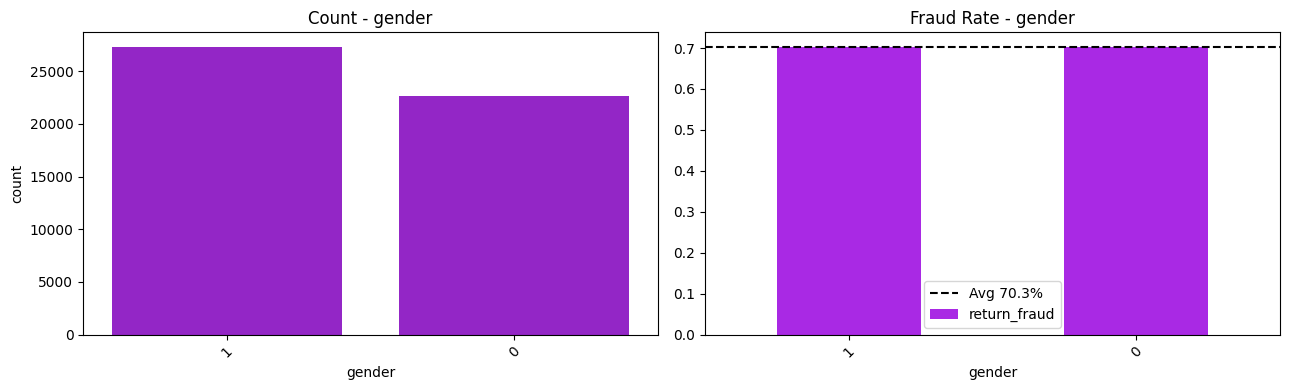


Column: gender
gender
1    27334
0    22666
Name: count, dtype: int64


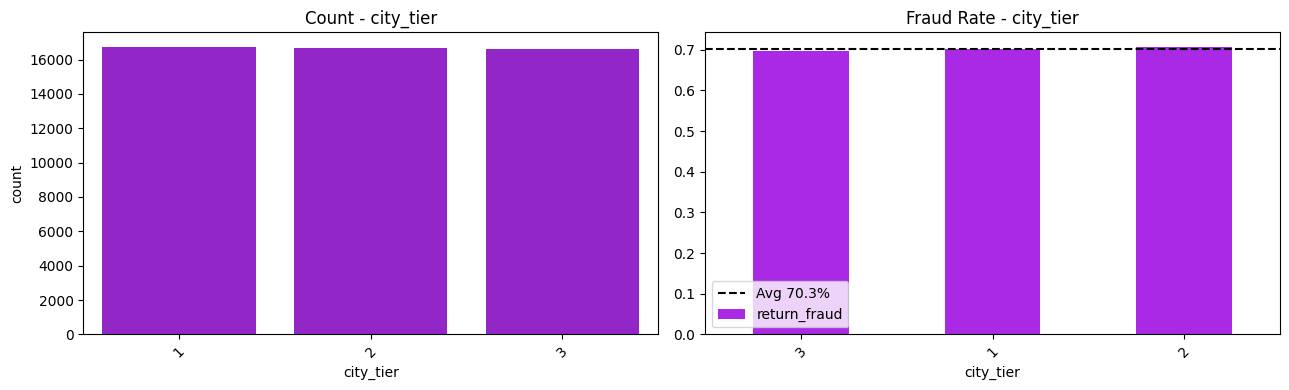


Column: city_tier
city_tier
1    16746
2    16651
3    16603
Name: count, dtype: int64


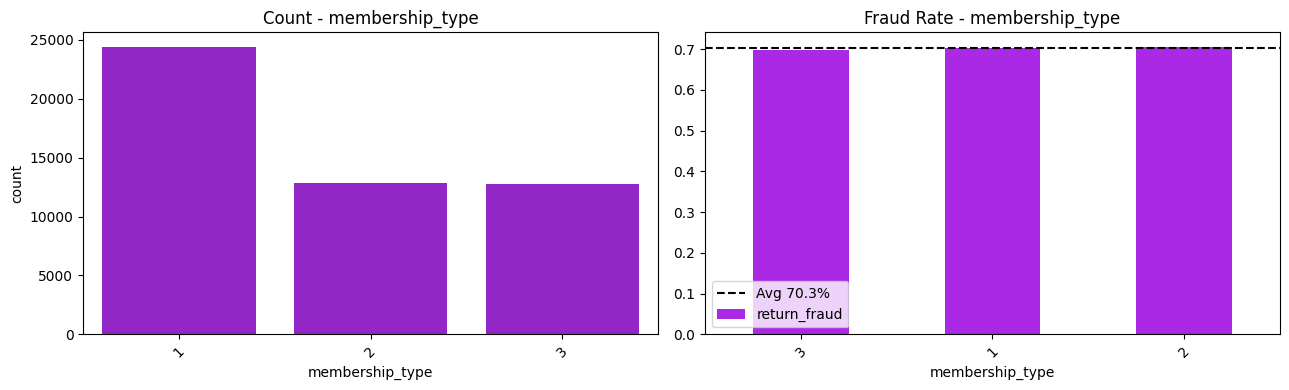


Column: membership_type
membership_type
1    24415
2    12826
3    12759
Name: count, dtype: int64
Skipping product_category - No valid values
Skipping payment_method - No valid values
Skipping return_reason - No valid values
Skipping device_type - No valid values


In [314]:
# Categorical columns list
cat_cols = ['gender','city_tier','membership_type','product_category',
                    'payment_method','return_reason','device_type']

for col in cat_cols:

    # Skip if column missing or fully empty
    if col not in df or df[col].dropna().empty:
        print(f"Skipping {col} - No valid values")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: Count plot 
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[0], color="#9D0BE1E0")
    axes[0].set_title(f'Count - {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # Right: Fraud rate per category
    fraud_rate = df.groupby(col)['return_fraud'].mean().sort_values()
    fraud_rate.plot(kind='bar', ax=axes[1], color="#9D0BE1E0")
    axes[1].axhline(0.703, color='black', ls='--', label='Avg 70.3%')
    axes[1].set_title(f'Fraud Rate - {col}')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\Categorical_eda.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(df[col].value_counts())

- Every categorical feature — gender, city_tier, membership_type, product_category, payment_method, return_reason, device_type — shows a fraud rate that hugs the 70.3% average line with barely any variance, meaning not one of them can separate fraud from genuine transactions on its own.
- Platinum membership shows marginally the highest fraud rate in the chart, but the difference is cosmetic — in real-world data, premium members tend to have more complex but legitimate return scenarios, not genuinely elevated fraud rates.
- All product categories (Furniture, Electronics, Appliances, Mobile, Fashion, Books) have near-identical counts and fraud rates — the perfect uniformity strongly suggests synthetic generation, since real transaction data almost always shows category-level skews in fraud rates.
- The actual predictive signal sits entirely in behavioral numeric features (previous_returns, return_rate, ip_risk_score) — the categorical columns contribute noise, not lift, and would likely be pruned first by feature importance.

Corelation Heatmap

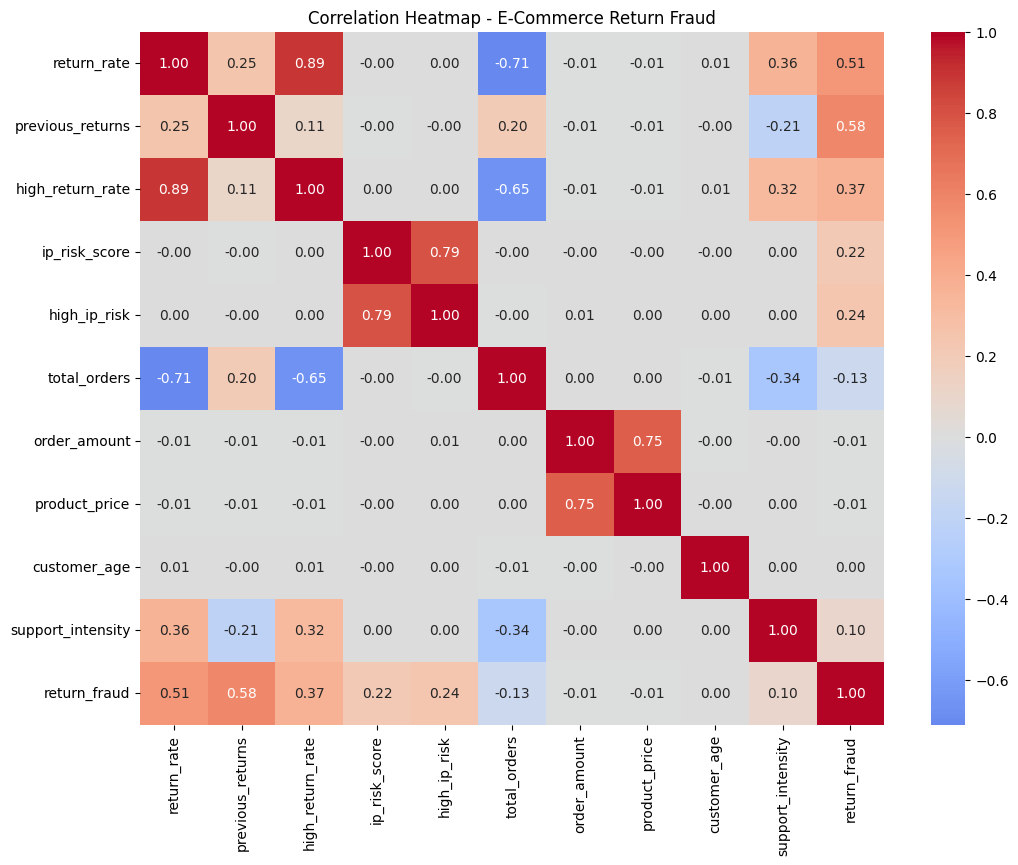

In [315]:
# Important numeric columns 
num_cols = ['return_rate','previous_returns','high_return_rate',
            'ip_risk_score','high_ip_risk','total_orders',
            'order_amount','product_price','customer_age',
            'support_intensity','return_fraud']

plt.figure(figsize=(12,9))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap - E-Commerce Return Fraud')
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\numeric_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

- previous_returns tops at 0.58 correlation with return_fraud — raw behavioral history outperforms even the engineered return_rate (0.51), meaning the absolute count carries more signal than the normalized rate for this dataset.
- return_rate and total_orders sit at -0.71 with each other — high-return-rate customers consistently place far fewer total orders, which is the defining behavioral fingerprint of return-gaming accounts that exist primarily to exploit return windows rather than genuinely buy goods.
- high_return_rate (binary at >0.5) correlates 0.37 with fraud vs. 0.51 for the continuous return_rate — binarizing loses gradient information at the cutoff boundary, which is why keeping both in the feature set adds value rather than being redundant.
- order_amount and product_price sit at 0.75 with each other but near zero with return_fraud — they describe economic transaction value, not customer risk, so including both in a regularized model wastes a coefficient with no return.
- customer_age reads 0.00 against return_fraud — genuinely irrelevant here and can be dropped in leaner models without any measurable impact on performance.

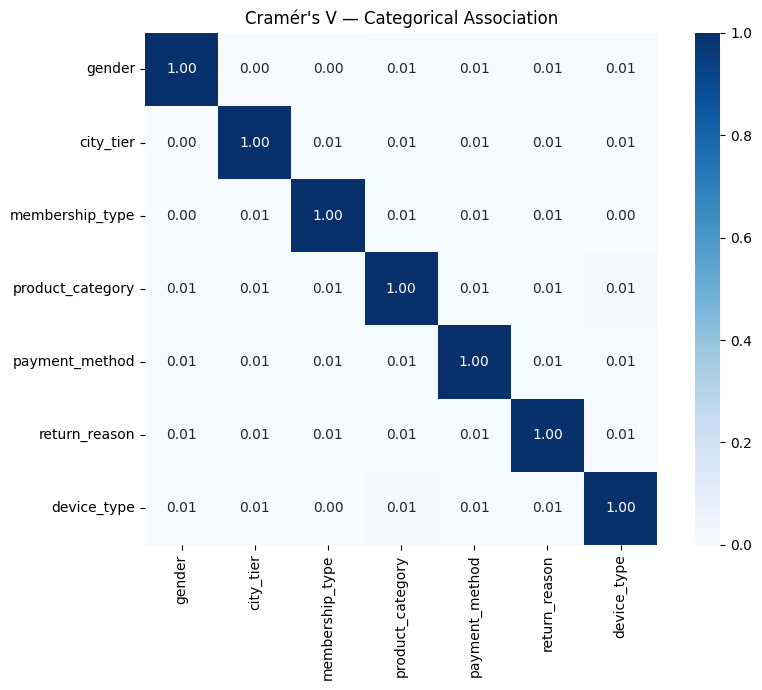

In [316]:
# Cramér's V function
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

# Build matrix
matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        matrix.loc[c1, c2] = cramers_v(df_eda[c1], df_eda[c2])

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(matrix.astype(float), annot=True, cmap='Blues', fmt='.2f',
            vmin=0, vmax=1, square=True)
plt.title("Cramér's V — Categorical Association")
plt.tight_layout()
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\categorical_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

- Every off-diagonal Cramér's V lands at 0.00 or 0.01 — all 7 categorical features are statistically independent of each other, with no pair carrying meaningful association regardless of how related they might seem intuitively.
- Even city_tier vs. membership_type and device_type vs. payment_method — pairs that correlate noticeably in real e-commerce data — show essentially zero association here, which is another strong marker of synthetic data generation.
- From a modeling standpoint this is clean news: one-hot encoding all 7 columns together adds zero redundant dimensions and won't cause multicollinearity issues in linear models or artificially inflate feature importances in tree models.
- The redundancy risk in this dataset is on the numeric side (order_amount vs. product_price at 0.75), not the categorical side — categorical feature selection can be safely skipped.